<a href="https://colab.research.google.com/github/Januar1717/steam-games-revenue-analysis/blob/main/Top_Game_Steam_Revenue.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎮 Steam Games Revenue Analysis 2024

Analisis ini bertujuan untuk mengetahui game Steam dengan **pendapatan (revenue) terbesar** berdasarkan dataset Steam 2024.

### Pertanyaan Analisis
> Game apa saja yang berhasil meraup pendapatan terbesar di Steam?

### Tahapan Analisis
1. Memuat dataset
2. Memahami struktur dan kualitas data
3. Menangani missing values
4. Mengubah format tanggal
5. Mengidentifikasi 5 game dengan revenue terbesar
6. Memvisualisasikan hasil analisis

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Load dataset
df = pd.read_csv("/content/sample_data/Steam_2024_bestRevenue_1500.csv")

# Menampilkan 5 data pertama
df.head()

,name,releaseDate,copiesSold,price,revenue,avgPlaytime,reviewScore,publisherClass,publishers,developers,steamId
0,WWE 2K24,07-03-2024,165301,99.99,8055097.0,42.365140,71,AAA,2K,Visual Concepts,2315690
1,EARTH DEFENSE FORCE 6,25-07-2024,159806,59.99,7882151.0,29.651061,57,Indie,D3PUBLISHER,SANDLOT,2291060
2,Sins of a Solar Empire II,15-08-2024,214192,49.99,7815247.0,12.452593,88,Indie,Stardock Entertainment,"Ironclad Games Corporation,Stardock Entertainment",1575940
3,Legend of Mortal,14-06-2024,440998,19.99,7756399.0,24.797817,76,Indie,"Paras Games,Obb Studio Inc.",Obb Studio Inc.,1859910
4,Shin Megami Tensei V: Vengeance,13-06-2024,141306,59.99,7629252.0,34.258496,96,AA,SEGA,ATLUS,1875830


## 🔎 1. Memahami Dataset

Sebelum melakukan analisis, kita perlu melihat struktur dataset dan memeriksa apakah terdapat data yang kosong.

In [ ]:
# Cek jumlah missing values pada setiap kolom
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

,0
publishers,1
developers,2


## 🧹 2. Data Cleaning

Ditemukan beberapa nilai kosong pada kolom `publishers` dan `developers`.

Karena informasi tersebut berupa data kategorikal, nilai kosong akan diisi dengan **"Unknown"** agar tidak menghilangkan baris data.

In [ ]:
# Mengisi missing values
df['publishers'] = df['publishers'].fillna('Unknown')
df['developers'] = df['developers'].fillna('Unknown')

# Mengubah releaseDate menjadi format datetime
df['releaseDate'] = pd.to_datetime(
    df['releaseDate'],
    format='%d-%m-%Y'
)

# Cek kembali missing values
print("Total missing values setelah cleaning:")
print(df.isnull().sum().sum())

Total missing values setelah cleaning:
0


## 💰 3. Top 5 Game Berdasarkan Revenue

Selanjutnya, kita akan mengurutkan seluruh game berdasarkan `revenue` dari yang terbesar hingga terkecil.

Kemudian, kita mengambil 5 game dengan pendapatan terbesar.

In [ ]:
# Mengambil nama game dan revenue
top_revenue = (
    df[['name', 'revenue']]
    .sort_values(by='revenue', ascending=False)
    .head(5)
    .reset_index(drop=True)
)

# Menambahkan ranking
top_revenue.index = top_revenue.index + 1
top_revenue.index.name = 'Rank'

top_revenue

,name,revenue
Rank,,
1,Black Myth: Wukong,837793356.0
2,HELLDIVERS™ 2,435635596.0
3,Palworld,392328553.0
4,Sons Of The Forest,217017892.0
5,Dragon's Dogma 2,111478291.0


## 📊 4. Visualisasi Revenue

Grafik berikut menunjukkan 5 game Steam dengan revenue terbesar berdasarkan dataset yang dianalisis.

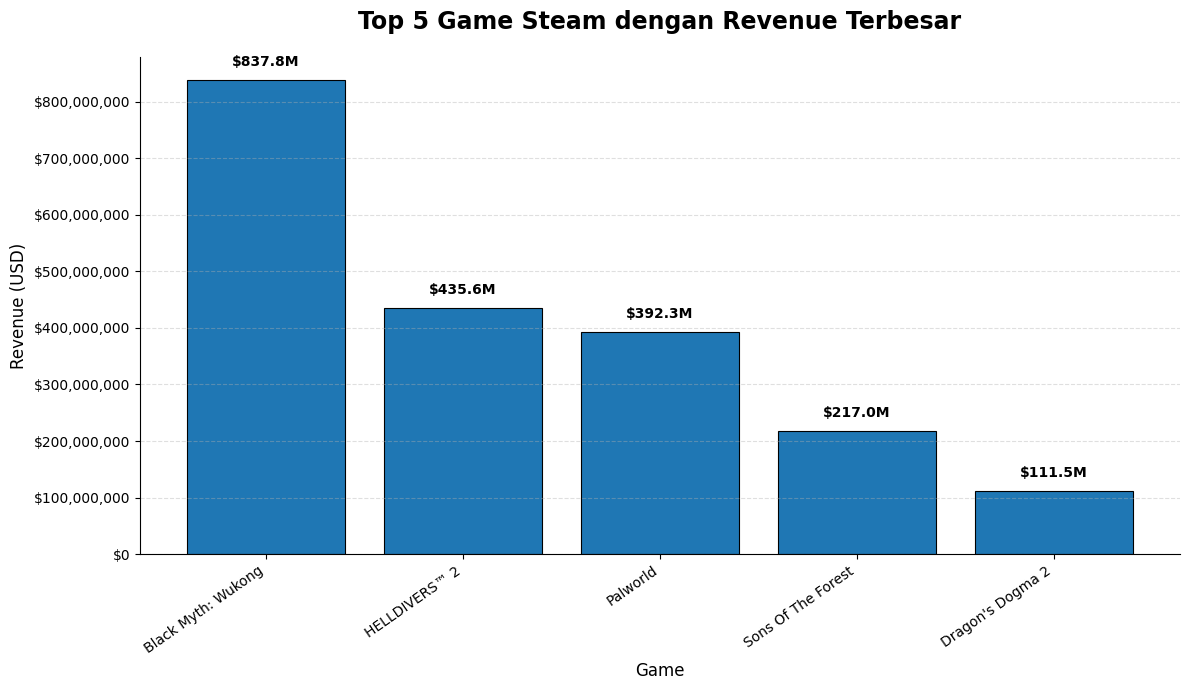

In [ ]:
# Menyiapkan data
data_plot = top_revenue.reset_index()

fig, ax = plt.subplots(figsize=(12, 7))

# Membuat bar chart
bars = ax.bar(
    data_plot['name'],
    data_plot['revenue'],
    edgecolor='black',
    linewidth=0.8
)

# Judul dan label
ax.set_title(
    'Top 5 Game Steam dengan Revenue Terbesar',
    fontsize=17,
    fontweight='bold',
    pad=20
)

ax.set_xlabel('Game', fontsize=12)
ax.set_ylabel('Revenue (USD)', fontsize=12)

# Rotasi nama game
ax.tick_params(
    axis='x',
    rotation=35,
    labelsize=10
)

# Format angka pada sumbu Y
ax.yaxis.set_major_formatter(
    ticker.StrMethodFormatter('${x:,.0f}')
)

# Menambahkan label revenue di atas bar
for bar in bars:
    height = bar.get_height()

    if height >= 1_000_000_000:
        label = f'${height / 1_000_000_000:.1f}B'
    elif height >= 1_000_000:
        label = f'${height / 1_000_000:.1f}M'
    else:
        label = f'${height:,.0f}'

    ax.annotate(
        label,
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 8),
        textcoords='offset points',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

# Grid
ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.4
)

# Menghilangkan border yang tidak diperlukan
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

## 💡 5. Key Insights

Berdasarkan hasil analisis, terdapat beberapa temuan utama:

- **[Black Myth: Wukong]** memiliki revenue terbesar dibandingkan game lainnya dalam dataset.
- Lima game dengan revenue terbesar menunjukkan adanya perbedaan yang cukup signifikan antara posisi pertama dan game lainnya.
- Revenue menjadi salah satu indikator yang dapat digunakan untuk melihat performa komersial game di Steam.
- Analisis lebih lanjut dapat dilakukan untuk mengetahui apakah revenue berkaitan dengan faktor lain seperti genre, harga, jumlah pemain, atau tanggal rilis.